#THEORY

## 1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where the model is not provided with labeled data. Instead, it tries to find hidden patterns, groupings, or structures in the input data on its own. Clustering and dimensionality reduction are common examples of unsupervised learning.

---

## 2. How does K-Means clustering algorithm work?

K-Means clustering partitions data into K clusters by iteratively performing the following steps:
1. Initialize K centroids randomly.
2. Assign each data point to the nearest centroid (cluster assignment).
3. Recalculate the centroids as the mean of the points in each cluster.
4. Repeat steps 2 and 3 until the centroids no longer change significantly or a maximum number of iterations is reached.

---

## 3. Explain the concept of a dendrogram in hierarchical clustering.

A dendrogram is a tree-like diagram used to visualize the arrangement of clusters created by hierarchical clustering. It shows how individual data points are merged into clusters step by step, and at what distance (or dissimilarity) the merges occur. Cutting the dendrogram at a certain level gives the desired number of clusters.

---

## 4. What is the main difference between K-Means and Hierarchical Clustering?

The main difference is:
- **K-Means** is a partitioning algorithm that requires specifying the number of clusters in advance.
- **Hierarchical Clustering** builds a hierarchy of clusters without needing to specify the number of clusters upfront and allows for dendrogram-based analysis.

---

## 5. What are the advantages of DBSCAN over K-Means?

- DBSCAN can find clusters of arbitrary shapes.
- It does not require specifying the number of clusters beforehand.
- It can identify noise/outliers.
- It's better suited for datasets with clusters of varying densities.

---

## 6. When would you use Silhouette Score in clustering?

Silhouette Score is used to evaluate the quality of clustering. It measures how similar a point is to its own cluster compared to other clusters. It is useful when comparing the performance of different clustering models or choosing the optimal number of clusters.

---

## 7. What are the limitations of Hierarchical Clustering?

- Computationally expensive for large datasets.
- Once a merge or split is done, it cannot be undone (greedy).
- Sensitive to noise and outliers.
- Choosing the number of clusters from the dendrogram can be subjective.

---

## 8. Why is feature scaling important in clustering algorithms like K-Means?

K-Means relies on distance metrics (like Euclidean distance). If features are on different scales, features with larger ranges can dominate the distance calculations, leading to biased clusters. Feature scaling ensures each feature contributes equally.

---

## 9. How does DBSCAN identify noise points?

DBSCAN classifies a point as noise if it is not a core point and does not fall within the neighborhood (ε) of any core point. These points are labeled as outliers and not assigned to any cluster.

---

## 10. Define inertia in the context of K-Means.

Inertia is the sum of squared distances between each data point and its assigned cluster centroid. It measures how internally coherent the clusters are. Lower inertia indicates tighter, more compact clusters.

---

## 11. What is the elbow method in K-Means clustering?

The elbow method helps determine the optimal number of clusters (K) by plotting the inertia for different K values. The point where the rate of decrease sharply slows down (forming an "elbow") is considered the ideal K.

---

## 12. Describe the concept of "density" in DBSCAN.

In DBSCAN, density refers to the number of points within a specified radius (ε) of a point. A point is considered a core point if the number of neighbors within this radius is at least `min_samples`.

---

## 13. Can hierarchical clustering be used on categorical data?

Yes, but standard distance metrics like Euclidean distance are not suitable for categorical data. Instead, specialized measures (e.g., Hamming distance) and algorithms (like Agglomerative Clustering with appropriate linkage and distance metrics) must be used.

---

## 14. What does a negative Silhouette Score indicate?

A negative Silhouette Score suggests that the sample might have been assigned to the wrong cluster, as it is closer to a neighboring cluster than to its own. It indicates poor clustering performance.

---

## 15. Explain the term "linkage criteria" in hierarchical clustering.

Linkage criteria determine how the distance between clusters is calculated during merging. Common types include:
- **Single linkage**: shortest distance between points in two clusters.
- **Complete linkage**: longest distance.
- **Average linkage**: average distance.
- **Ward linkage**: minimizes the variance within clusters.

---

## 16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

K-Means assumes equal-sized, spherical clusters with similar densities. It may:
- Split larger clusters.
- Merge small clusters.
- Misclassify points near cluster boundaries.

---

## 17. What are the core parameters in DBSCAN, and how do they influence clustering?

The two core parameters are:
- `ε` (epsilon): the radius within which to search for neighboring points.
- `min_samples`: the minimum number of points required to form a dense region (core point).
These parameters determine the shape and number of clusters and how noise is identified.

---

## 18. How does K-Means++ improve upon standard K-Means initialization?

K-Means++ chooses initial centroids more strategically by spreading them out based on distance, reducing the chances of poor clustering results and improving convergence speed and clustering quality.

---

## 19. What is agglomerative clustering?

Agglomerative clustering is a type of hierarchical clustering that starts with each data point as its own cluster and iteratively merges the closest pair of clusters until only one cluster remains or a desired number of clusters is reached.

---

## 20. What makes Silhouette Score a better metric than just inertia for model evaluation?

Inertia only measures compactness and decreases with more clusters, which can be misleading. Silhouette Score considers both cohesion (intra-cluster similarity) and separation (inter-cluster dissimilarity), providing a more balanced evaluation of clustering quality.


#PRACTICAL

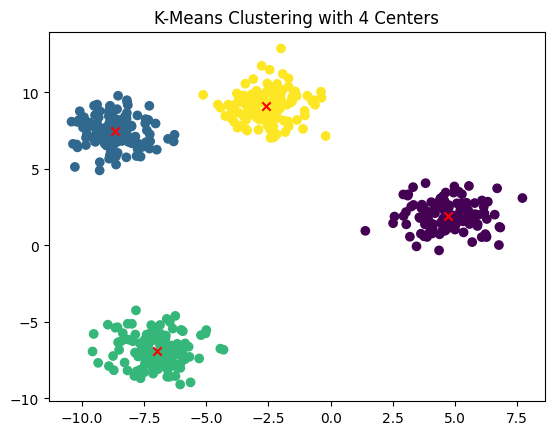

In [ ]:
# 21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=500, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='x')
plt.title("K-Means Clustering with 4 Centers")
plt.show()


In [ ]:
# 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)

print("First 10 predicted cluster labels:", labels[:10])



First 10 predicted cluster labels: [1 1 1 1 1 1 1 1 1 1]


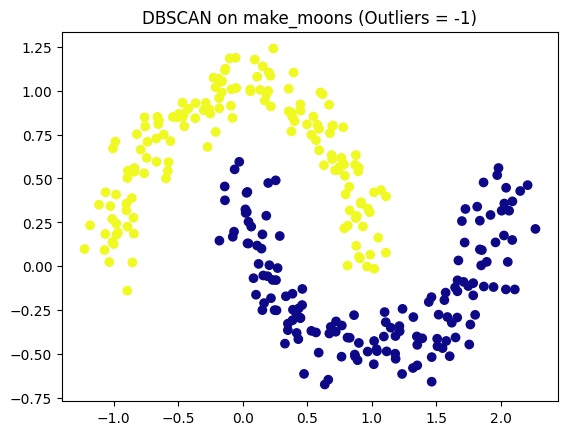

In [ ]:
# 23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title("DBSCAN on make_moons (Outliers = -1)")
plt.show()


In [3]:
# 24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans # Make sure this import statement is executed before using KMeans

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

(unique, counts) = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

Cluster sizes: {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


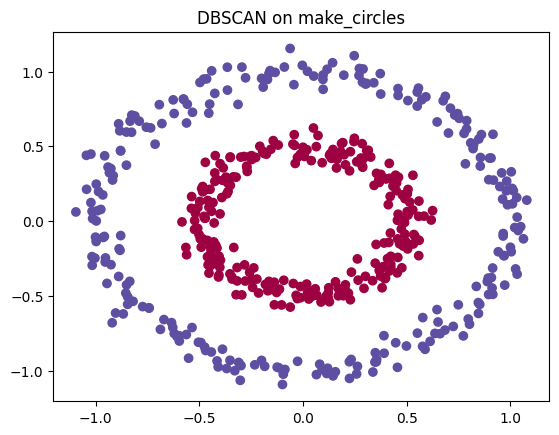

In [6]:
# 25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN # Make sure to import DBSCAN
import matplotlib.pyplot as plt # Make sure to import matplotlib.pyplot


X, _ = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Spectral')
plt.title("DBSCAN on make_circles")
plt.show()

In [5]:
# 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X = MinMaxScaler().fit_transform(data.data)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

print("Cluster Centroids:\n", kmeans.cluster_centers_)


Cluster Centroids:
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


In [ ]:
# 27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Accent')
plt.title("DBSCAN on blobs with varying std devs")
plt.show()


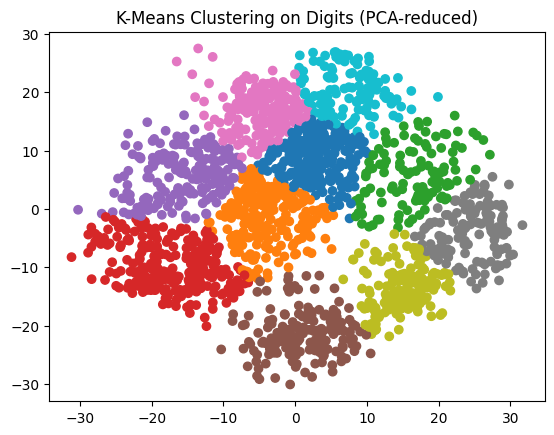

In [8]:
# 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
plt.title("K-Means Clustering on Digits (PCA-reduced)")
plt.show()


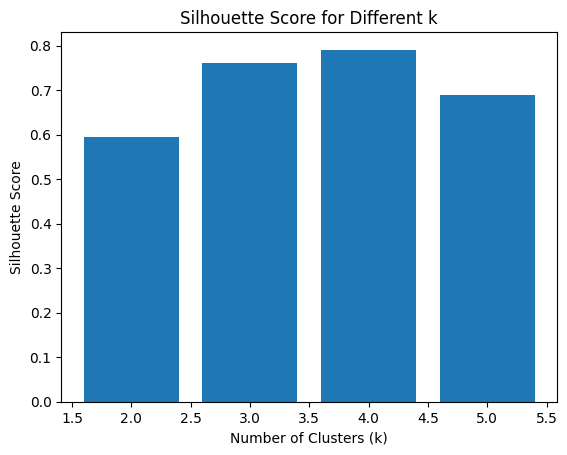

In [9]:
# 29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
scores = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.bar(range(2, 6), scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.show()


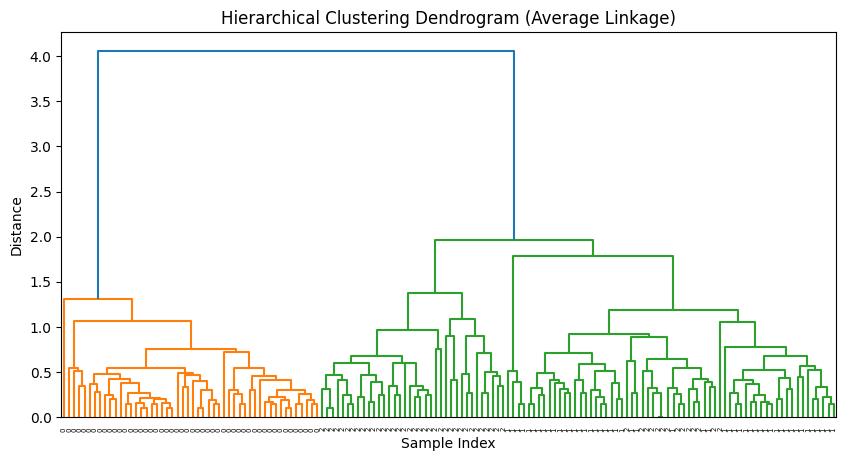

In [10]:
# 30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

iris = load_iris()
Z = linkage(iris.data, method='average')

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=iris.target)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


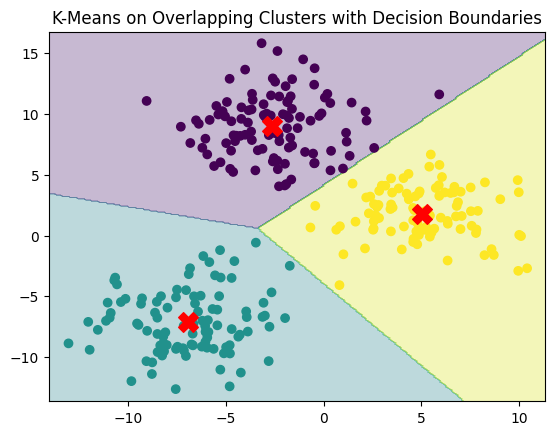

In [11]:
# 31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels = kmeans.labels_

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title("K-Means on Overlapping Clusters with Decision Boundaries")
plt.show()


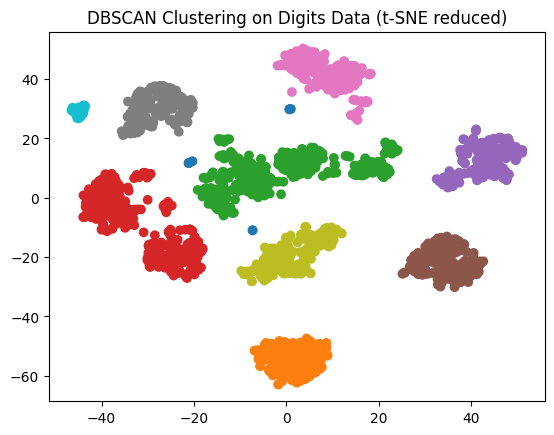

In [12]:
# 32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
dbscan = DBSCAN(eps=5, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10')
plt.title("DBSCAN Clustering on Digits Data (t-SNE reduced)")
plt.show()


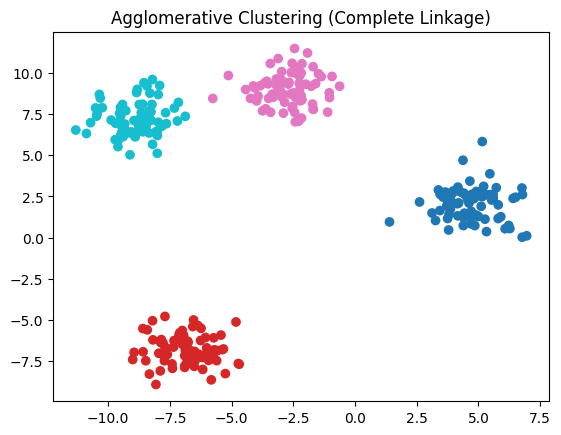

In [13]:
# 33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10')
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()


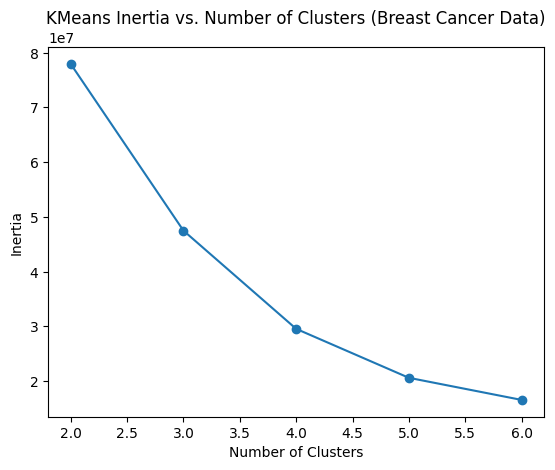

In [14]:
# 34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
inertias = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(2, 7), inertias, marker='o')
plt.title("KMeans Inertia vs. Number of Clusters (Breast Cancer Data)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


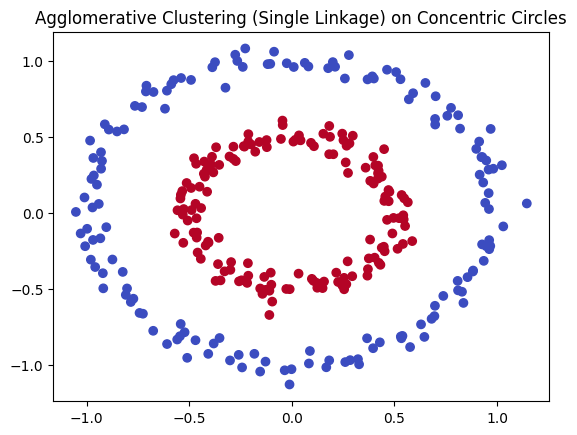

In [15]:
# 35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05)
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm')
plt.title("Agglomerative Clustering (Single Linkage) on Concentric Circles")
plt.show()


In [16]:
# 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

data = load_wine()
X = StandardScaler().fit_transform(data.data)
db = DBSCAN(eps=1.5, min_samples=5).fit(X)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters (excluding noise):", n_clusters)


Number of clusters (excluding noise): 0


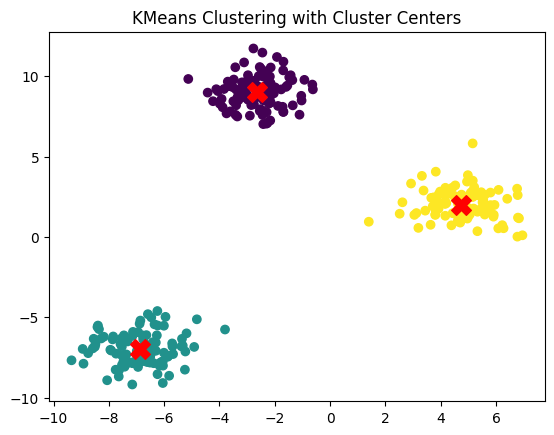

In [17]:
# 37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title("KMeans Clustering with Cluster Centers")
plt.show()


In [18]:
# 38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
dbscan = DBSCAN(eps=0.8, min_samples=5).fit(X)
noise_points = np.sum(dbscan.labels_ == -1)
print("Number of noise points:", noise_points)


Number of noise points: 4


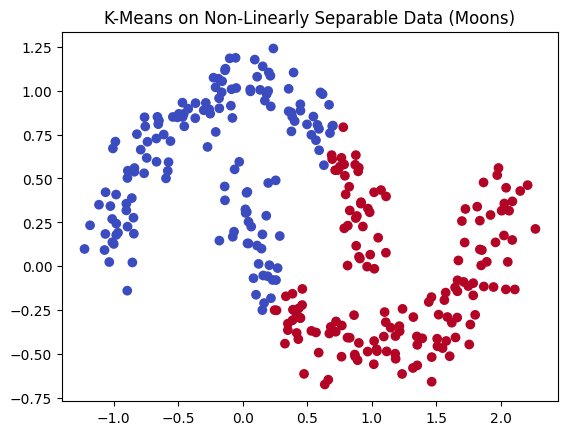

In [19]:
# 39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='coolwarm')
plt.title("K-Means on Non-Linearly Separable Data (Moons)")
plt.show()


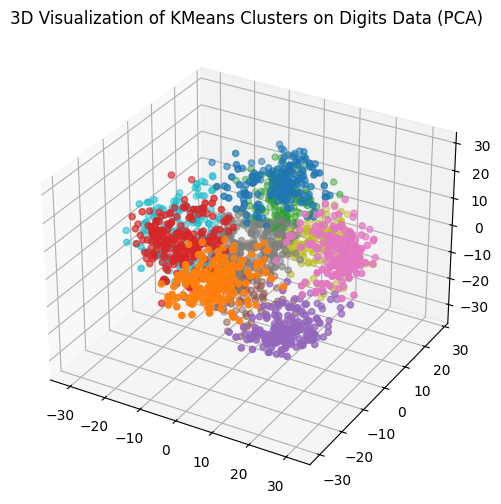

In [20]:
# 40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
X_pca = PCA(n_components=3).fit_transform(digits.data)
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans.labels_, cmap='tab10')
ax.set_title("3D Visualization of KMeans Clusters on Digits Data (PCA)")
plt.show()


In [21]:
# 41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=5, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.678738720085253


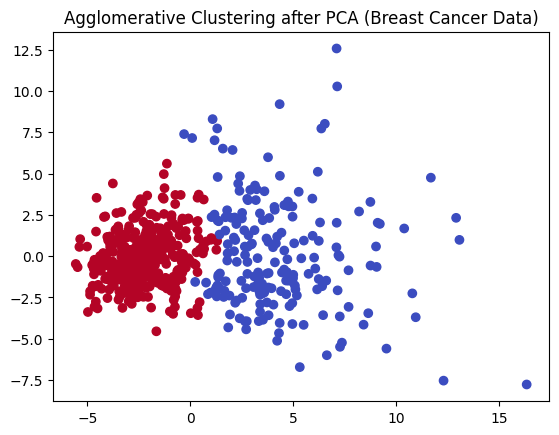

In [22]:
# 42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

data = load_breast_cancer()
X_scaled = StandardScaler().fit_transform(data.data)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm')
plt.title("Agglomerative Clustering after PCA (Breast Cancer Data)")
plt.show()


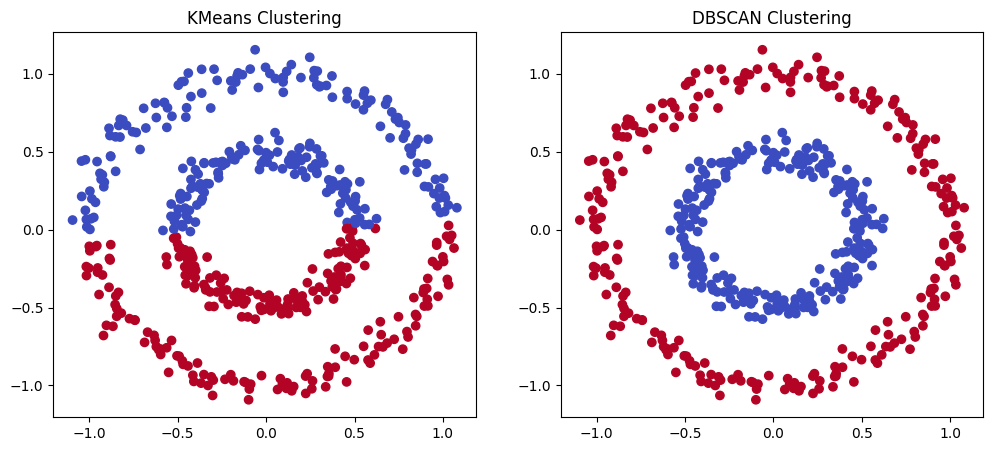

In [23]:
# 43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42).fit_predict(X)
dbscan = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans, cmap='coolwarm')
axs[0].set_title("KMeans Clustering")
axs[1].scatter(X[:, 0], X[:, 1], c=dbscan, cmap='coolwarm')
axs[1].set_title("DBSCAN Clustering")
plt.show()


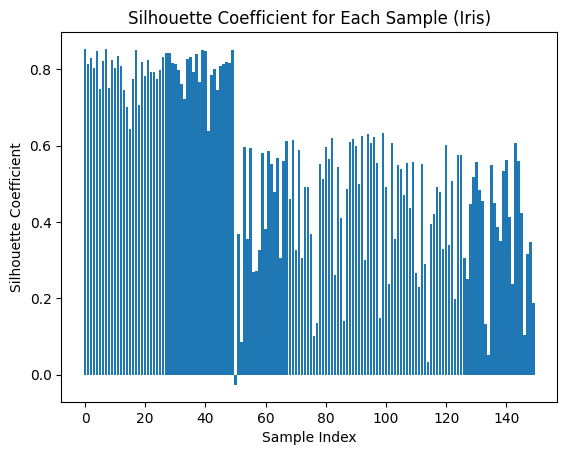

In [24]:
# 44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

data = load_iris()
X = data.data
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
silhouette_vals = silhouette_samples(X, kmeans.labels_)

plt.bar(range(len(silhouette_vals)), silhouette_vals)
plt.title("Silhouette Coefficient for Each Sample (Iris)")
plt.xlabel("Sample Index")
plt.ylabel("Silhouette Coefficient")
plt.show()


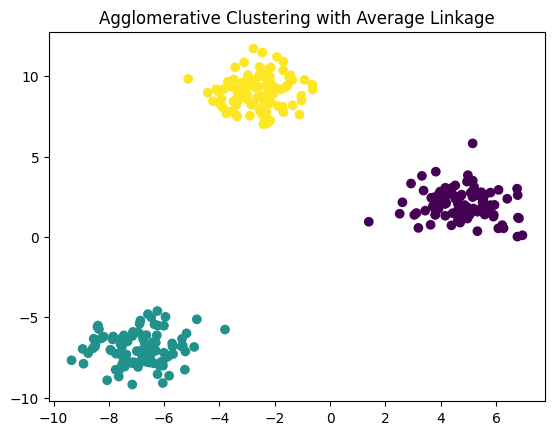

In [25]:
# 45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)
agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Agglomerative Clustering with Average Linkage")
plt.show()


KeyError: 'cluster'

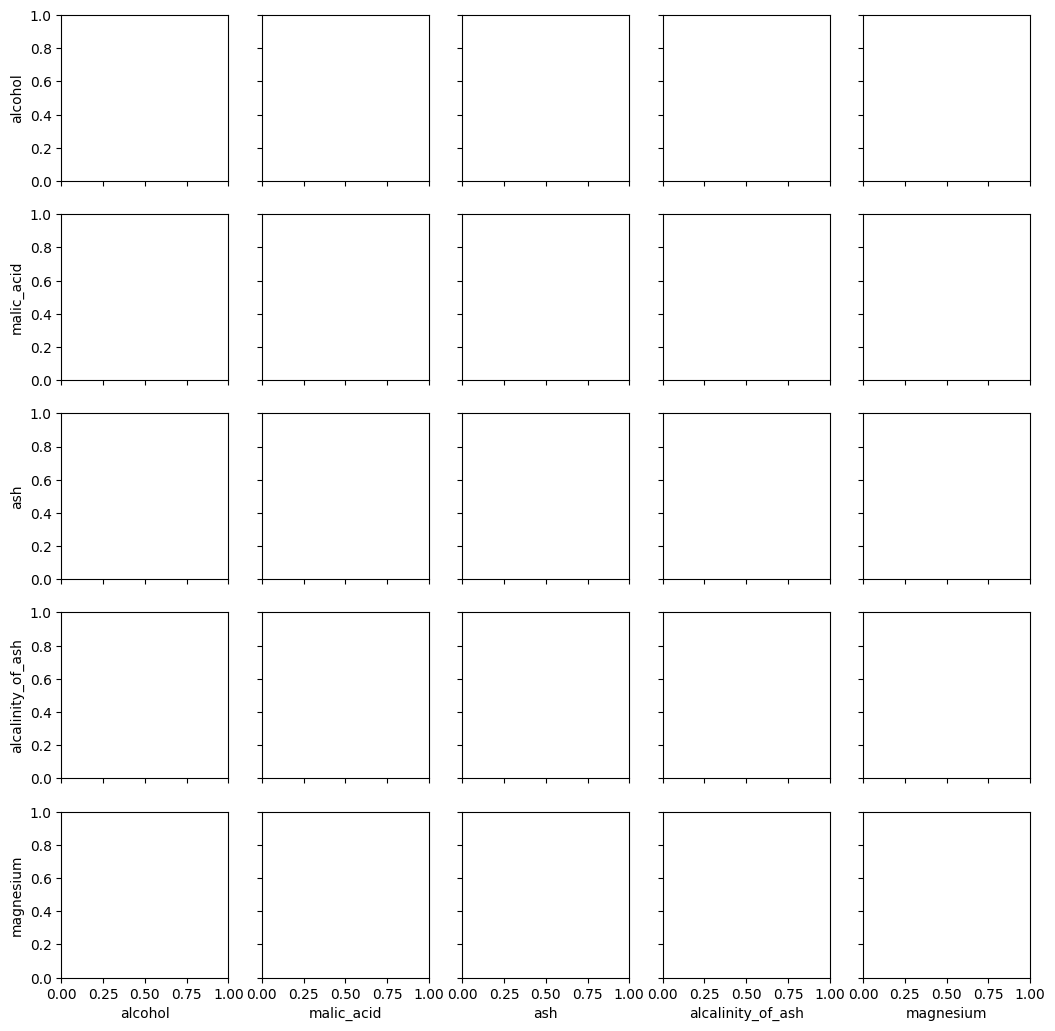

In [26]:
# 46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['cluster'] = KMeans(n_clusters=3, random_state=42).fit_predict(data.data)

sns.pairplot(df.iloc[:, :5], hue='cluster', palette='husl')
plt.suptitle("KMeans Clustering on Wine Dataset (First 4 Features)", y=1.02)
plt.show()



In [27]:
# 47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

X, _ = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=42)
X[:20] += np.random.uniform(-8, 8, X[:20].shape)  # Add noise
dbscan = DBSCAN(eps=1.2, min_samples=5).fit(X)

labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)


Clusters: 4
Noise points: 21


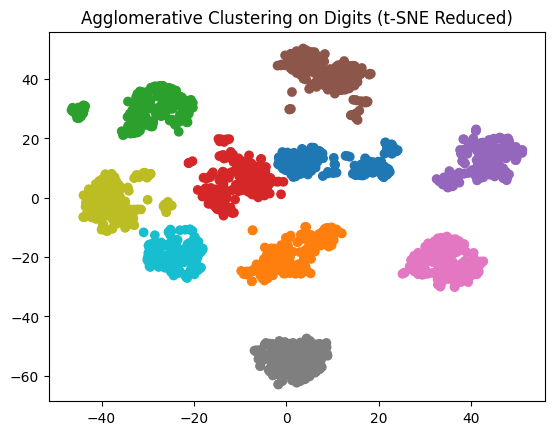

In [28]:
# 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

digits = load_digits()
X_reduced = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
agg = AgglomerativeClustering(n_clusters=10).fit(X_reduced)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=agg.labels_, cmap='tab10')
plt.title("Agglomerative Clustering on Digits (t-SNE Reduced)")
plt.show()
